## Propensity Score Matching

Replicates the first-stage matching procedure from Mamkhezri, Sun & Yang (2026).

**Approach:**
1. Define treatment: census tract has at least one data center
2. Estimate propensity scores via probit model using pre-treatment ACS demographics
3. Match each treated tract to its 10 nearest untreated neighbors (10-NN with replacement)
4. Exclude treated tracts outside common support
5. Check covariate balance before and after matching

**Covariates (from paper, Section 5.1):**
- Population
- % White residents
- % High school graduates
- Median household income
- Number of housing units

In [6]:
import pandas as pd
import numpy as np
from pathlib import Path
import statsmodels.api as sm
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import warnings
import geopandas as gpd
warnings.filterwarnings('ignore')

DATA_DIR = next(
    p / "data" for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "data").exists()
)
OUTPUT_DIR = next(
    p / "output" for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "output").exists()
)

usa_dir = DATA_DIR / "processed" / "usa_data"
census_raw_dir = DATA_DIR / "raw" / "census_data"
lmp_processed_dir = DATA_DIR / "processed" / "pjm_lmp_data"
matching_dir = DATA_DIR / "processed" / "matching"

In [2]:
# Load ACS demographic data
acs = pd.read_csv(census_raw_dir / "va_acs_2016_tract.csv", dtype={"GEOID": str})
print("ACS shape:", acs.shape)

# Load data center file
dc = pd.read_excel(OUTPUT_DIR / "datacenters_matched_tracts.xlsx",
                   dtype={"census_tract_geoid": str})
print("Data centers shape:", dc.shape)
print("\nData center columns:", dc.columns.tolist())

ACS shape: (1866, 10)
Data centers shape: (319, 43)

Data center columns: ['id', 'state_im3', 'state_abb', 'state_id', 'county', 'county_id', 'operator', 'ref', 'name', 'sqft', 'lon', 'lat', 'type', 'im3_id', 'fractracker_facility_name', 'fractracker_address', 'fractracker_city', 'zip', 'fractracker_county', 'fractracker_lat', 'fractracker_lon', 'fractracker_status', 'fractracker_location_confidence', 'fractracker_operator_name', 'fractracker_mw', 'sizerank', 'facility_size_sqft', 'property_size_acres', 'other_info', 'information_source', 'fractracker_id', 'match_distance_m', 'matched_flag', 'match_quality', 'name_similarity', 'research_year', 'year_basis_used', 'year_source_link', 'census_tract_geoid', 'census_tract_name', 'census_statefp', 'census_countyfp', 'census_tractce']


In [3]:
# Restrict ACS to only tracts that have at least one LMP pricing node
# Tracts without pnodes have no observable electricity prices and cannot be used in DiD
lmp = pd.read_csv(lmp_processed_dir / "va_lmp_yearly_avg_load_geo.csv", dtype={"census_geoid": str})
tracts_with_lmp = set(lmp["census_geoid"].dropna().unique())

acs = acs[acs["GEOID"].isin(tracts_with_lmp)].copy()
print(f"ACS tracts after restricting to tracts with LMP data: {len(acs)}")
print(f"  (dropped {1868 - len(acs)} tracts with no pricing nodes)")

ACS tracts after restricting to tracts with LMP data: 350
  (dropped 1518 tracts with no pricing nodes)


In [13]:
missing_tracts = census[census["GEOID"].isin(missing_geoids)][["STATEFP", "COUNTYFP", "TRACTCE", "GEOID", "NAME", "NAMELSAD", "MTFCC", "FUNCSTAT", "ALAND", "AWATER"]]                 
print(missing_tracts.to_string()) 

     STATEFP COUNTYFP TRACTCE        GEOID  NAME           NAMELSAD  MTFCC FUNCSTAT     ALAND  AWATER
445       51      670  980100  51670980100  9801  Census Tract 9801  G5020        S   5940771   10627
538       51      059  980200  51059980200  9802  Census Tract 9802  G5020        S  10021952   16045
943       51      013  980100  51013980100  9801  Census Tract 9801  G5020        S   4890529       0
950       51      135  980100  51135980100  9801  Census Tract 9801  G5020        S  90179993  464441
1315      51      059  980300  51059980300  9803  Census Tract 9803  G5020        S   2321064    3941


These counties all have population = 0 (checked by manually confirming on census website). Therefore they have no ACS data that can be used for matching. 

In [14]:
# Compute first data center entry year per tract                                                                                                                                       
first_entry = (                                                                                                                                                                        
    dc.dropna(subset=["census_tract_geoid", "research_year"])                                                                                                                          
    .groupby("census_tract_geoid")["research_year"]                                                                                                                                    
    .min()      
    .reset_index()                                                                                                                                                                     
    .rename(columns={"census_tract_geoid": "census_geoid", "research_year": "first_entry_year"})
)                                                                                                                                                                                      
                
print("First entry year distribution:")
print(first_entry["first_entry_year"].value_counts().sort_index())

First entry year distribution:
first_entry_year
1992    1
1998    1
1999    1
2000    4
2001    2
2002    2
2004    1
2006    2
2009    2
2010    1
2012    1
2013    1
2015    1
2016    1
2017    7
2018    1
2019    2
2020    1
2021    2
2022    2
2023    2
2024    5
2026    1
2027    2
Name: count, dtype: int64


In [15]:
# Create treatment indicator: 1 if tract has at least one data center
treated_geoids = set(dc["census_tract_geoid"].dropna().unique())
print(f"Treated tracts (with data centers): {len(treated_geoids)}")

acs["treated"] = acs["GEOID"].isin(treated_geoids).astype(int)
print(f"Treated in ACS: {acs['treated'].sum()}")
print(f"Untreated in ACS: {(acs['treated'] == 0).sum()}")

print("ACS GEOID sample:", acs["GEOID"].head(3).tolist())
print("DC GEOID sample:", dc["census_tract_geoid"].dropna().head(3).tolist())
print("\nACS GEOID dtype:", acs["GEOID"].dtype)
print("DC GEOID dtype:", dc["census_tract_geoid"].dtype)

Treated tracts (with data centers): 46
Treated in ACS: 13
Untreated in ACS: 337
ACS GEOID sample: ['51550021403', '51003011400', '51081880200']
DC GEOID sample: ['51087201404', '51153901504', '51153901503']

ACS GEOID dtype: str
DC GEOID dtype: str


In [19]:
# Restrict treated group to tracts with first entry 2017-2025
# (excludes always-treated and not-yet-treated units)
valid_treated_geoids = first_entry[                                                                                                                                                    
    (first_entry["first_entry_year"] >= 2017) &
    (first_entry["first_entry_year"] <= 2025)                                                                                                                                          
]["census_geoid"]
                                                                                                                                                                                        
acs["treated"] = acs["GEOID"].isin(valid_treated_geoids).astype(int)                                                                                                                   

print(f"Treated (first DC 2017-2025): {acs['treated'].sum()}")                                                                                                                         
print(f"Untreated: {(acs['treated'] == 0).sum()}")
print(f"Total: {len(acs)}") 

# Tracts that were treated under old definition but dropped by year filter                                                                                                             
dropped = first_entry[first_entry["census_geoid"].isin(                                                                                                                                
    set(dc["census_tract_geoid"].dropna().unique()) - set(valid_treated_geoids)
)]                                   
print(f"Tracts that were dropped:")                                                                                                                                                  
print(dropped.sort_values("first_entry_year"))

Treated (first DC 2017-2025): 8
Untreated: 342
Total: 350
Tracts that were dropped:
   census_geoid  first_entry_year
1   51059460501              1992
17  51107611006              1998
26  51107611702              1999
3   51059471201              2000
21  51107611020              2000
24  51107611502              2000
23  51107611501              2000
6   51059481900              2001
13  51087200904              2001
2   51059460503              2002
38  51153901421              2002
39  51153901503              2004
5   51059481202              2006
8   51059490104              2006
0   51047930400              2009
20  51107611019              2009
18  51107611015              2010
36  51153901418              2012
32  51117930600              2013
14  51087201404              2015
9   51059980100              2016
31  51107980100              2026
22  51107611028              2027
40  51153901504              2027


In [ ]:
# Exclude always-treated tracts from control pool
ever_treated_geoids = set(dc["census_tract_geoid"].dropna().unique())
                                                                                                                                                                                        
n_removed = ((acs["treated"] == 0) & (acs["GEOID"].isin(ever_treated_geoids))).sum()                                                                                                   
acs = acs[~((acs["treated"] == 0) & (acs["GEOID"].isin(ever_treated_geoids)))].copy()                                                                                                  
                                                                                                                                                                                                                                                                                                  
print(f"Treated: {acs['treated'].sum()} | Untreated: {(acs['treated'] == 0).sum()}")
print(f"Total: {len(acs)}") 

Treated: 8 | Untreated: 337
Total: 345


In [32]:
# Define covariates for probit model (matching the paper's specification)                                                                                                              
covariates = [                                                                                                                                                                         
    "total_population",                                                                                                                                                                
    "pct_white",                                                                                                                                                                       
    "pct_hs_or_above",
    "median_household_income",                                                                                                                                                         
    "total_housing_units",
]                                                                                                                                                                                      
                                                                                                                                                                                        
# Drop rows with missing values in covariates or outcome
df = acs[["GEOID", "NAME", "treated"] + covariates].dropna()                                                                                                                           
print(f"Rows after dropping NaN: {len(df)} (dropped {len(acs) - len(df)})")                                                                                                            
print(f"Treated: {df['treated'].sum()} | Untreated: {(df['treated'] == 0).sum()}") 

Rows after dropping NaN: 345 (dropped 0)
Treated: 8 | Untreated: 337


In [33]:
# Estimate propensity scores via probit model
X = sm.add_constant(df[covariates])
y = df["treated"]

probit_model = sm.Probit(y, X).fit()
print(probit_model.summary())

df["propensity_score"] = probit_model.predict(X)

Optimization terminated successfully.
         Current function value: 0.089830
         Iterations 8
                          Probit Regression Results                           
Dep. Variable:                treated   No. Observations:                  345
Model:                         Probit   Df Residuals:                      339
Method:                           MLE   Df Model:                            5
Date:                Mon, 20 Apr 2026   Pseudo R-squ.:                  0.1849
Time:                        12:50:21   Log-Likelihood:                -30.991
converged:                       True   LL-Null:                       -38.019
Covariance Type:            nonrobust   LLR p-value:                   0.01526
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -2.3153      2.783     -0.832      0.406      -7.771   

In [34]:
# 10-nearest neighbor matching with replacement
# Common support: exclude treated tracts whose propensity score exceeds
# the maximum propensity score of untreated tracts

treated = df[df["treated"] == 1].copy()
untreated = df[df["treated"] == 0].copy()

# Common support cutoff
max_untreated_ps = untreated["propensity_score"].max()
treated_in_support = treated[treated["propensity_score"] <= max_untreated_ps]
excluded = treated[treated["propensity_score"] > max_untreated_ps]

print(f"Treated tracts in common support: {len(treated_in_support)}")
print(f"Treated tracts excluded (outside support): {len(excluded)}")
if len(excluded) > 0:
    print("Excluded tracts:", excluded[["GEOID", "NAME", "propensity_score"]].values)

# Fit k-NN on untreated propensity scores
k = 10
knn = NearestNeighbors(n_neighbors=k, metric="euclidean")
knn.fit(untreated[["propensity_score"]])

# Find 10 nearest untreated neighbors for each treated tract in support
distances, indices = knn.kneighbors(treated_in_support[["propensity_score"]])

# Build matched sample
matched_untreated_indices = indices.flatten()
matched_untreated = untreated.iloc[matched_untreated_indices].copy()

# Count how many times each untreated tract appears (for weighting)
match_counts = pd.Series(matched_untreated_indices).value_counts()
matched_untreated["match_count"] = matched_untreated.reset_index(drop=True).index.map(
    lambda i: match_counts.get(matched_untreated_indices[i], 1)
    if i < len(matched_untreated_indices) else 1
)

# Assign weights: inverse of match count
untreated_idx = untreated.index.tolist()
count_by_idx = {untreated_idx[i]: count for i, count in match_counts.items()}
matched_untreated_unique = untreated[untreated.index.isin(count_by_idx.keys())].copy()
matched_untreated_unique["weight"] = matched_untreated_unique.index.map(
    lambda i: 1 / count_by_idx[i]
)

treated_in_support["weight"] = 1.0

print(f"\nUnique untreated tracts matched: {len(matched_untreated_unique)}")
print(f"Treated tracts in matched sample: {len(treated_in_support)}")

Treated tracts in common support: 8
Treated tracts excluded (outside support): 0

Unique untreated tracts matched: 44
Treated tracts in matched sample: 8


In [35]:
# Check covariate balance before and after matching
def standardized_diff(treated_vals, control_vals):
    """Standardized difference: (mean_treated - mean_control) / pooled_std"""
    mean_diff = treated_vals.mean() - control_vals.mean()
    pooled_std = np.sqrt((treated_vals.var() + control_vals.var()) / 2)
    return mean_diff / pooled_std if pooled_std > 0 else np.nan

balance = []
for cov in covariates:
    # Before matching
    std_diff_before = standardized_diff(
        df[df["treated"] == 1][cov],
        df[df["treated"] == 0][cov]
    )
    # After matching
    std_diff_after = standardized_diff(
        treated_in_support[cov],
        matched_untreated_unique[cov]
    )
    balance.append({
        "covariate": cov,
        "std_diff_before": round(std_diff_before, 3),
        "std_diff_after": round(std_diff_after, 3)
    })

balance_df = pd.DataFrame(balance)
print("Covariate Balance (standardized differences):")
print(balance_df.to_string(index=False))
print("\nNote: Values closer to 0 indicate better balance")

Covariate Balance (standardized differences):
              covariate  std_diff_before  std_diff_after
       total_population            0.162           0.117
              pct_white           -0.255           0.236
        pct_hs_or_above            0.901          -0.032
median_household_income            1.621           0.326
    total_housing_units           -0.531           0.139

Note: Values closer to 0 indicate better balance


In [36]:
#Check statistical significance
from scipy import stats                                                                                                                                                                  
                                                                                                                                                                                        
print("Statistical significance of differences before and after matching:\n")                                                                                                            
print(f"{'Covariate':<30} {'p_before':>10} {'p_after':>10}")                                                                                                                           
print("-" * 52)                                                                                                                                                                          
                                                                                                                                                                                        
for cov in covariates:                                                                                                                                                                   
    # Before matching                                                                                                                                                                  
    t_before, p_before = stats.ttest_ind(                                                                                                                                                
        df[df["treated"] == 1][cov],
        df[df["treated"] == 0][cov]                                                                                                                                                      
    )                                                                                                                                                                                  
    # After matching
    t_after, p_after = stats.ttest_ind(                                                                                                                                                  
        treated_in_support[cov],
        matched_untreated_unique[cov]                                                                                                                                                    
    )                                                                                                                                                                                  
    sig_before = "***" if p_before < 0.01 else "**" if p_before < 0.05 else "*" if p_before < 0.1 else ""
    sig_after = "***" if p_after < 0.01 else "**" if p_after < 0.05 else "*" if p_after < 0.1 else ""                                                                                    
    print(f"{cov:<30} {p_before:>9.3f}{sig_before:>1} {p_after:>9.3f}{sig_after:>1}")                                                                                                    
                                                                                                                                                                                        
print("\n* p<0.10  ** p<0.05  *** p<0.01") 

Statistical significance of differences before and after matching:

Covariate                        p_before    p_after
----------------------------------------------------
total_population                   0.641      0.763 
pct_white                          0.566      0.599 
pct_hs_or_above                    0.056*     0.944 
median_household_income            0.000***     0.440 
total_housing_units                0.187      0.738 

* p<0.10  ** p<0.05  *** p<0.01


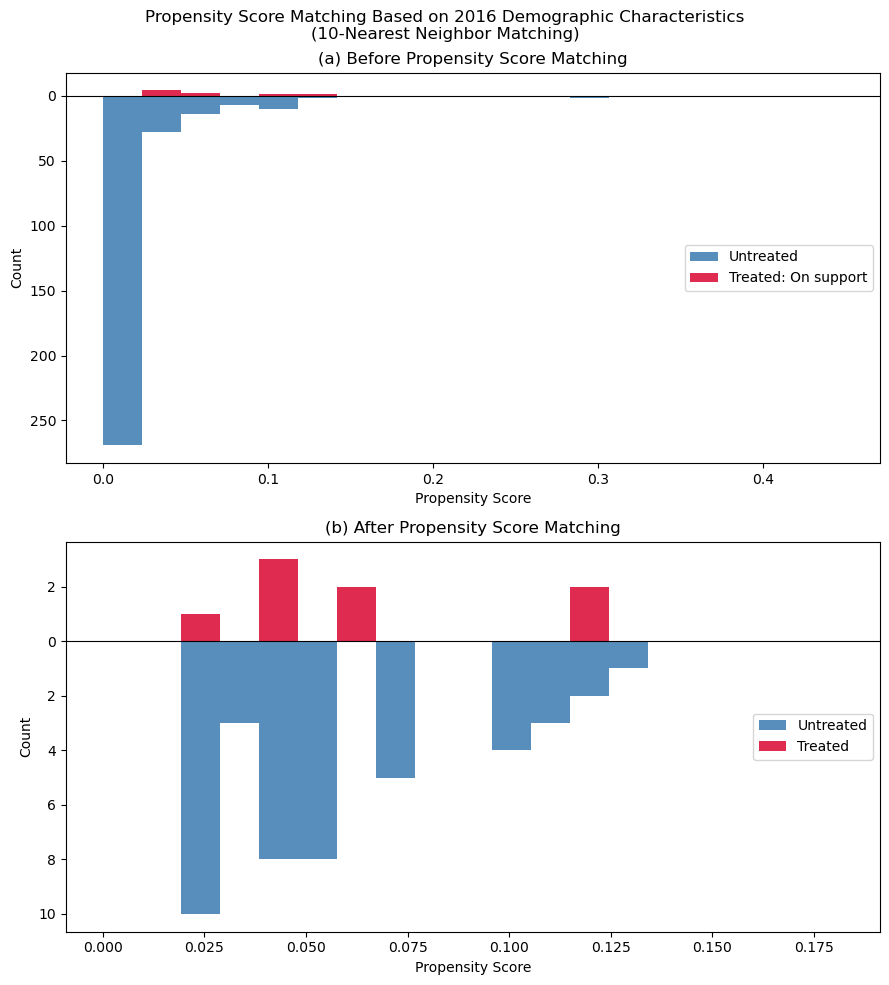

In [37]:
#Plot propensity score distributions before and after matching
fig, axes = plt.subplots(2, 1, figsize=(9, 10))                                                                                                                                        
                                                                                                                                                                                        
bins = np.linspace(0, df["propensity_score"].max() + 0.05, 20)                                                                                                                         
                                                                                                                                                                                        
# --- Panel (a): Before matching ---                                                                                                                                                   
ax = axes[0]    
                                                                                                                                                                                        
untreated_ps = df[df["treated"] == 0]["propensity_score"]
treated_on_ps = treated_in_support["propensity_score"]                                                                                                                                 
treated_off_ps = excluded["propensity_score"]  # outside common support                                                                                                                
                                                                                                                                                                                        
# Untreated bars go downward                                                                                                                                                           
ax.hist(untreated_ps, bins=bins, color="steelblue", alpha=0.9, label="Untreated",                                                                                                      
        weights=np.ones(len(untreated_ps)) * -1)                                                                                                                                       
# Treated on support bars go upward                                                                                                                                                    
ax.hist(treated_on_ps, bins=bins, color="crimson", alpha=0.9, label="Treated: On support")                                                                                             
# Treated off support                                                                                                                                                                  
if len(treated_off_ps) > 0:                                                                                                                                                            
    ax.hist(treated_off_ps, bins=bins, color="mediumseagreen", alpha=0.9, label="Treated: Off support")                                                                                
                                                                                                                                                                                        
ax.axhline(0, color="black", linewidth=0.8)                                                                                                                                            
ax.set_xlabel("Propensity Score")                                                                                                                                                      
ax.set_ylabel("Count")                                                                                                                                                                 
ax.set_title("(a) Before Propensity Score Matching")
ax.legend(loc="right")                                                                                                                                                                 
# Flip y-axis labels to positive
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: str(int(abs(x)))))                                                                                                         
                                                                                                                                                                                        
# --- Panel (b): After matching ---                                                                                                                                                    
ax = axes[1]                                                                                                                                                                           
                
bins2 = np.linspace(0, max(treated_in_support["propensity_score"].max(),                                                                                                               
                            matched_untreated_unique["propensity_score"].max()) + 0.05, 20)
                                                                                                                                                                                        
control_ps = matched_untreated_unique["propensity_score"]
                                                                                                                                                                                        
ax.hist(control_ps, bins=bins2, color="steelblue", alpha=0.9, label="Untreated",                                                                                                       
        weights=np.ones(len(control_ps)) * -1)
ax.hist(treated_in_support["propensity_score"], bins=bins2, color="crimson", alpha=0.9, label="Treated")                                                                               
                                                                                                                                                                                        
ax.axhline(0, color="black", linewidth=0.8)                                                                                                                                            
ax.set_xlabel("Propensity Score")                                                                                                                                                      
ax.set_ylabel("Count")                                                                                                                                                                 
ax.set_title("(b) After Propensity Score Matching")
ax.legend(loc="right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: str(int(abs(x)))))                                                                                                         

fig.suptitle("Propensity Score Matching Based on 2016 Demographic Characteristics\n(10-Nearest Neighbor Matching)",                                                                    
            fontsize=12)
plt.tight_layout()                                                                                                                                                                     
plt.show() 

In [38]:
#Check average propensity score distance between matched pairs
print("Average propensity score distance between matched pairs:")                                                                                                                        
print(f"Treated mean: {treated_in_support['propensity_score'].mean():.4f}")                                                                                                              
print(f"Control mean: {matched_untreated_unique['propensity_score'].mean():.4f}")  

Average propensity score distance between matched pairs:
Treated mean: 0.0642
Control mean: 0.0580


In [39]:
# Save matched sample
matched_sample = pd.concat([
    treated_in_support.assign(group="treated"),
    matched_untreated_unique.assign(group="control")
], ignore_index=True)

matched_sample.to_csv(matching_dir / "va_matched_tracts.csv", index=False)
print(f"Saved {len(matched_sample):,} rows to va_matched_tracts.csv")
print(f"  Treated: {(matched_sample['group'] == 'treated').sum()}")
print(f"  Control: {(matched_sample['group'] == 'control').sum()}")

Saved 52 rows to va_matched_tracts.csv
  Treated: 8
  Control: 44
